# Quickstart Guide: Stress Sequences with the DEPRESS Dataset

This guide walks you through social sequence analysis using real data from the **DEPRESS** study (Dataset on Emotions, Performance, Responses, Environment, and Satisfaction during COVID-19).

**What is DEPRESS?** DEPRESS is a longitudinal dataset on college students’ mental health and learning during the COVID-19 pandemic (Guo et al., 2026, *Scientific Data*). It was collected at Worcester Polytechnic Institute from **June 2020 to June 2021** and includes three cohorts (semesters): **Summer 2020**, **Fall 2020**, and **Spring 2021**. Each participant joined one cohort and completed weekly surveys. Among other measures, participants answered the **4-item Perceived Stress Scale (PSS-4)** each week. In this tutorial we use PSS to build **stress level sequences** over 8 weeks (Low / Medium / High) and see how students cluster into different stress patterns.

New to Python? No problem—Sequenzo is designed to be intuitive and beginner-friendly.

**By the end of this tutorial you will:**

1. Load and explore the stress sequence data
2. Define sequence states (Low, Medium, High) from PSS scores
3. Visualize and compare sequences (index plots, state distribution, mean time, etc.)
4. Run clustering and interpret three clusters of stress trajectories

Let’s get started! 🐍✨


## 1. Get a rough idea of the data

In [1]:
# Import necessary libraries
# Your calling code (e.g., in a script or notebook)

from sequenzo import * # Import the package, give it a short alias
import pandas as pd # Data manipulation

# List all the available datasets in Sequenzo
# Now access functions using the alias:
print('Available datasets in Sequenzo: ', list_datasets())

# Load the data that we would like to explore in this tutorial
# `df` is the short for `dataframe`, which is a common variable name for a dataset

df = load_dataset('students_stress_states_by_week')

# Show the dataframe
df

Available datasets in Sequenzo:  ['biofam', 'biofam_child_domain', 'biofam_left_domain', 'biofam_married_domain', 'chinese_colonial_territories', 'country_child_mortality_global_deciles', 'country_co2_emissions', 'country_co2_emissions_global_deciles', 'country_co2_emissions_global_quintiles', 'country_co2_emissions_local_deciles', 'country_co2_emissions_local_quintiles', 'country_gdp_per_capita_quintiles', 'country_life_expectancy_global_deciles', 'dyadic_children', 'dyadic_parents', 'mvad', 'pairfam_activity_by_month', 'pairfam_activity_by_year', 'pairfam_family_by_month', 'pairfam_family_by_year', 'political_science_aid_shock', 'political_science_donor_fragmentation', 'students_stress_states_by_week']


,participant_id,cohort,1,2,3,4,5,6,7,8
0,Fall 100,Fall,M,L,L,L,L,L,H,L
1,Fall 101,Fall,M,M,M,M,M,L,L,M
2,Fall 102,Fall,M,M,M,M,M,M,L,L
3,Fall 103,Fall,L,L,M,L,H,L,M,M
4,Fall 104,Fall,L,L,L,L,L,L,M,L
...,...,...,...,...,...,...,...,...,...,...
84,Spring 149,Spring,M,M,L,L,L,M,M,L
85,Spring 15,Spring,H,M,M,M,M,M,M,M
86,Spring 150,Spring,L,M,L,L,M,L,M,M
87,Spring 170,Spring,H,M,M,M,M,M,M,L


**How are the three states defined?** In the DEPRESS study, stress was measured each week with the **4-item Perceived Stress Scale (PSS-4)**. PSS-4 responses are coded (e.g. “Never” = 0, “Almost Never” = 1, …, “Very Often” = 4); the score for each week is the average of the four items, so it ranges from **0 to 4**. For sequence analysis, each week’s score is then turned into one of three **states**:

* **Low (L)** – Lower perceived stress (e.g. lower end of the PSS range)
* **Medium (M)** – Moderate perceived stress
* **High (H)** – Higher perceived stress (e.g. higher end of the PSS range)

In social sequence analysis, each of these categories is called a **state**, and the ordered list of states over the 8 weeks is called a **social sequence**. In our dataframe, each **row** is one participant and **columns 1–8** are their stress state in weeks 1–8. For example, a sequence `M, L, L, L, L, L, H, L` means: medium stress in week 1, low in weeks 2–6, high in week 7, and low again in week 8.  

## 2. Analyze Social Sequences with Sequenzo

In [2]:
# Create a SequenceData object

# Define the time-span variable
time_list = list(df.columns)[2:]

# states = ['L', 'M', 'H', 'VH']
states = ['L', 'M', 'H']
# labels = ['Low', 'Medium', 'High', 'Very High']
labels = ['Low', 'Medium', 'High']

sequence_data = SequenceData(df, 
                             time=time_list, 
                             id_col="participant_id", 
                             states=states,
                             labels=labels)

sequence_data


[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 89
[>] Number of time points: 8
[>] Min/Max sequence length: 8 / 8
[>] States: ['L', 'M', 'H']
[>] Labels: ['Low', 'Medium', 'High']
[>] Weights: Not provided


SequenceData(89 sequences, States: ['L', 'M', 'H'])

## Visualization

Among the various visualization methods, the most commonly used one is the **index plot**. Let's see how it works.

Now we have successfully created the `SequenceData` object from our dataframe. This is the core object in Sequenzo for analyzing social sequences.

Looking at the raw data, we can only easily inspect one participant at a time. With Sequenzo, we can analyze and visualize all participants' stress sequences at once. The most important tool is visualization (e.g., the sequence index plot) which helps us see patterns and trends, such as which weeks tend to be high-stress and how stress evolves over the 8 weeks.

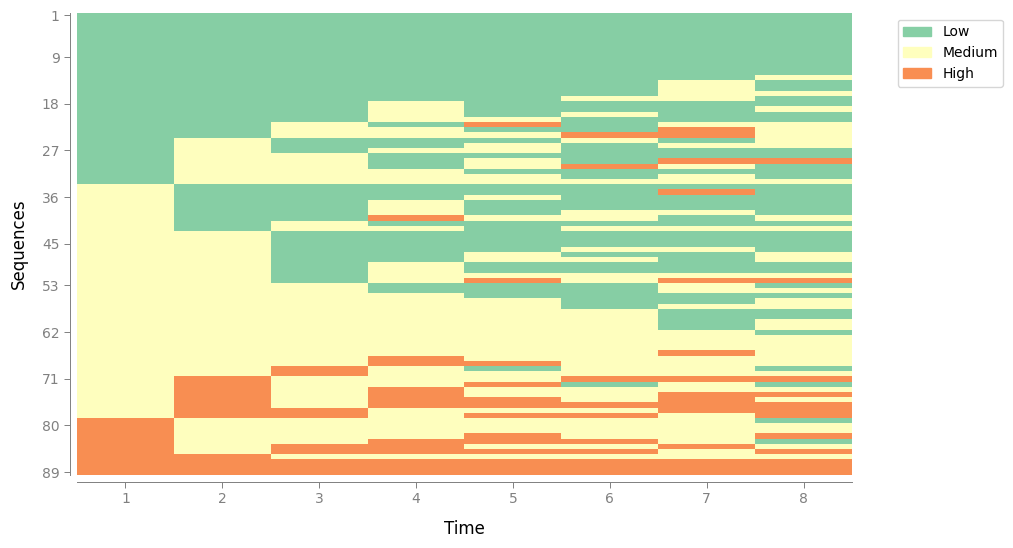

In [3]:
# Plot the index plot

plot_sequence_index(sequence_data, 
                    # save_as='index_plot',
                    )

[>] Reminder: You passed `group_column_name` but not `group_dataframe`.
    • `group_column_name` is used together with `group_dataframe` (e.g. a separate table with cluster membership).
    • To group by a column that is already in your sequence data, use `group_by_column` instead (e.g. group_by_column='cohort').
    Proceeding with a single (ungrouped) plot.


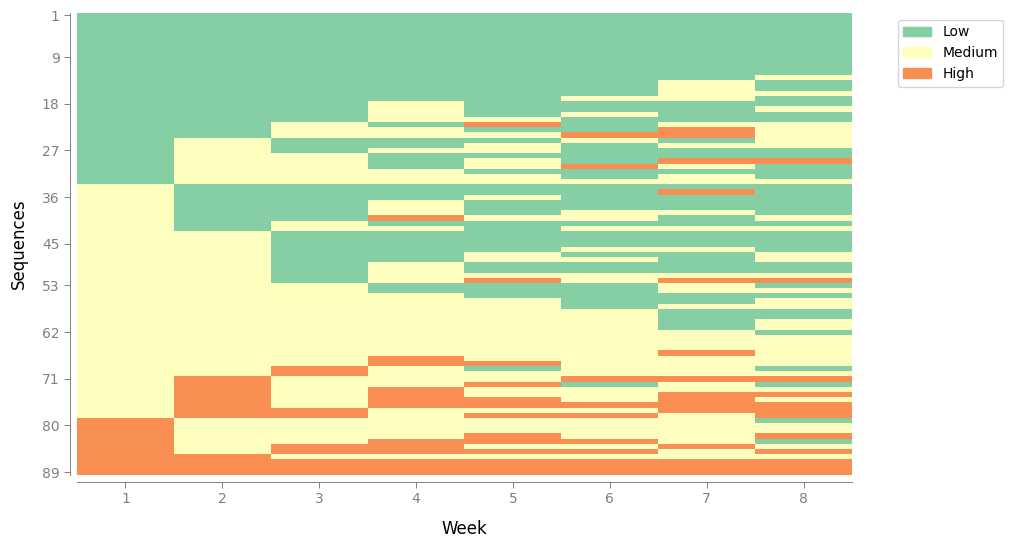

In [4]:
# Plot the index plot

plot_sequence_index(sequence_data, 
                    group_column_name='cohort',
                    xlabel='Week',
                    # save_as='index_plot',
                    )

[>] Creating grouped plots by 'cohort' with 2 categories


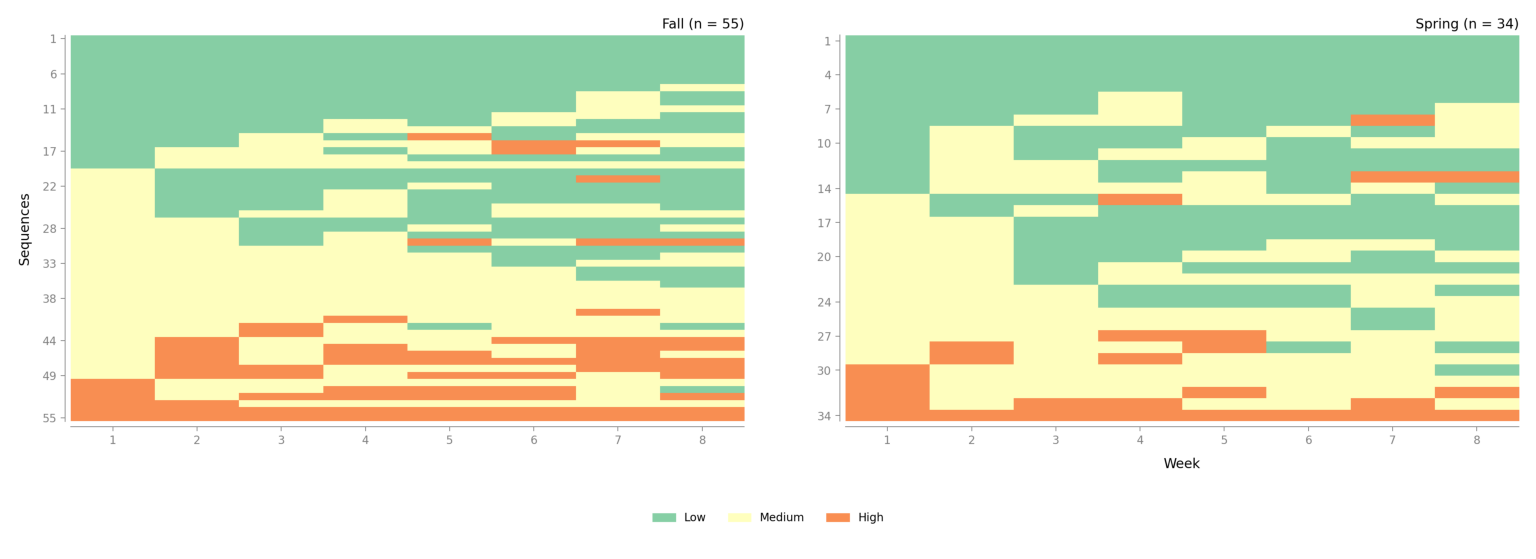

In [5]:
# Plot the index plot

plot_sequence_index(sequence_data, 
                    group_by_column='cohort',
                    xlabel='Week',
                    # save_as='index_plot',
                    )

Stress heterogeneity appears structurally stable across pandemic stages.

But what if we would like to know more? state distribution plot. 

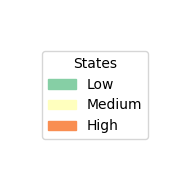

In [6]:
sequence_data.plot_legend(
                        # save_as="legend_plot"
                        )

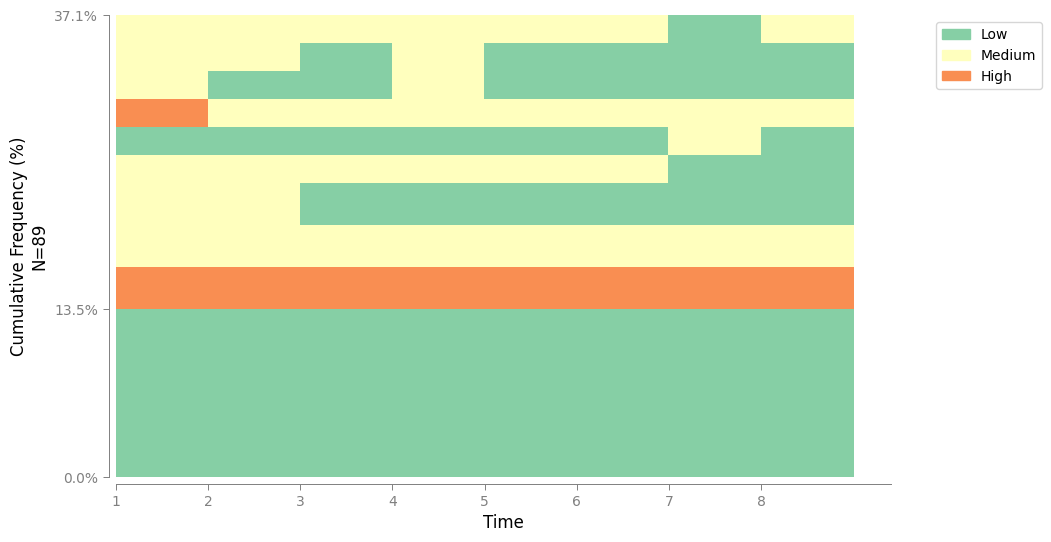

In [7]:
# Note: `plot_most_frequent_sequences` does not divide frequencies evenly; it’s just that in the stress data, the top sequences vary in frequency.

plot_most_frequent_sequences(sequence_data, top_n=10)

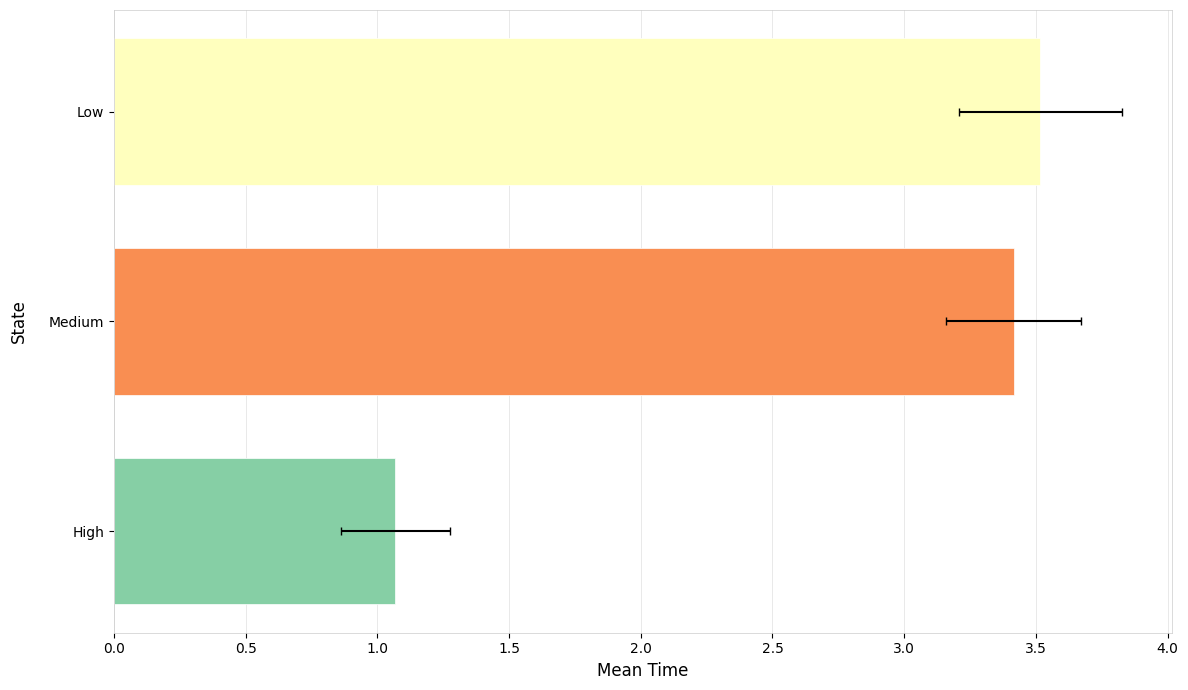

In [8]:
plot_mean_time(sequence_data,
               # save_as='mean_time'
               )

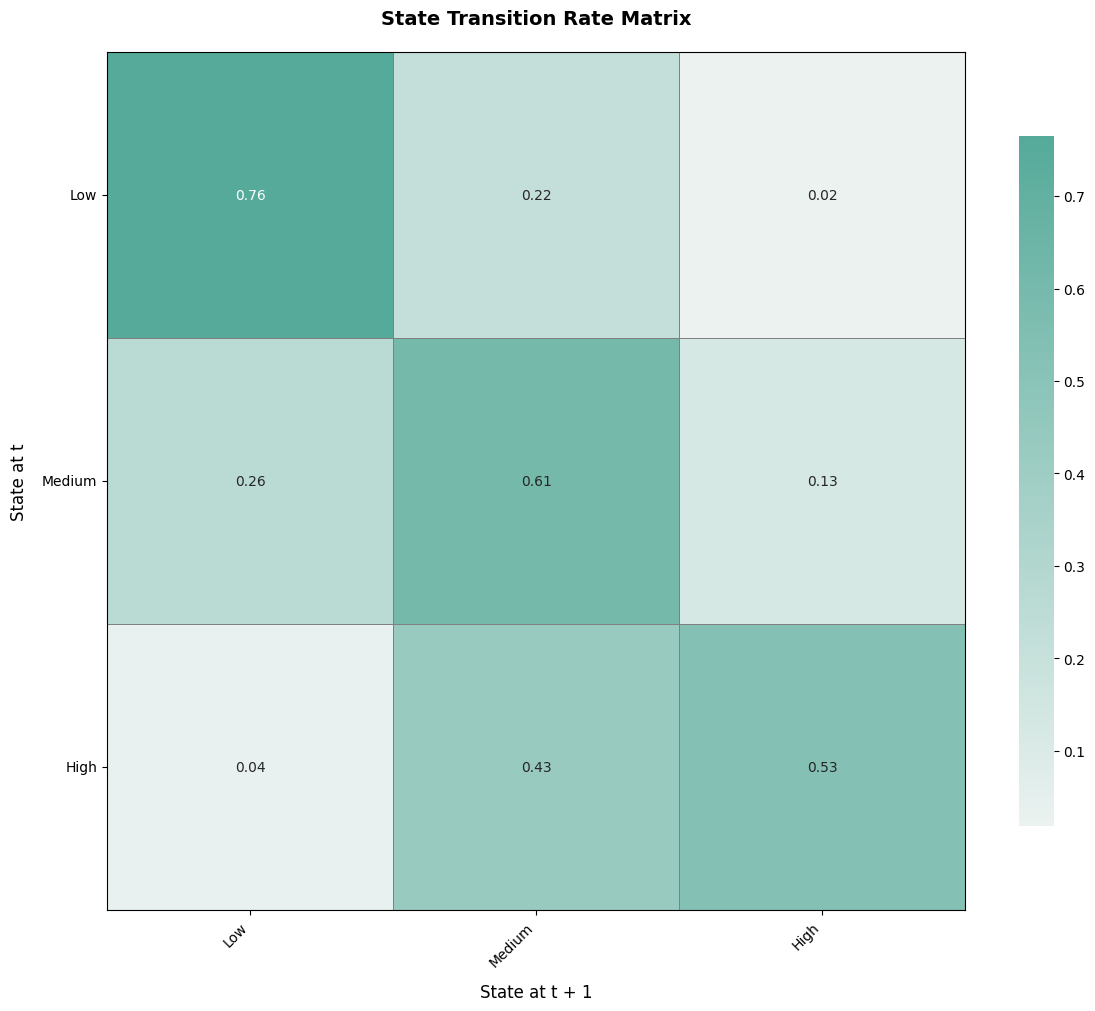

In [9]:
plot_transition_matrix(sequence_data)


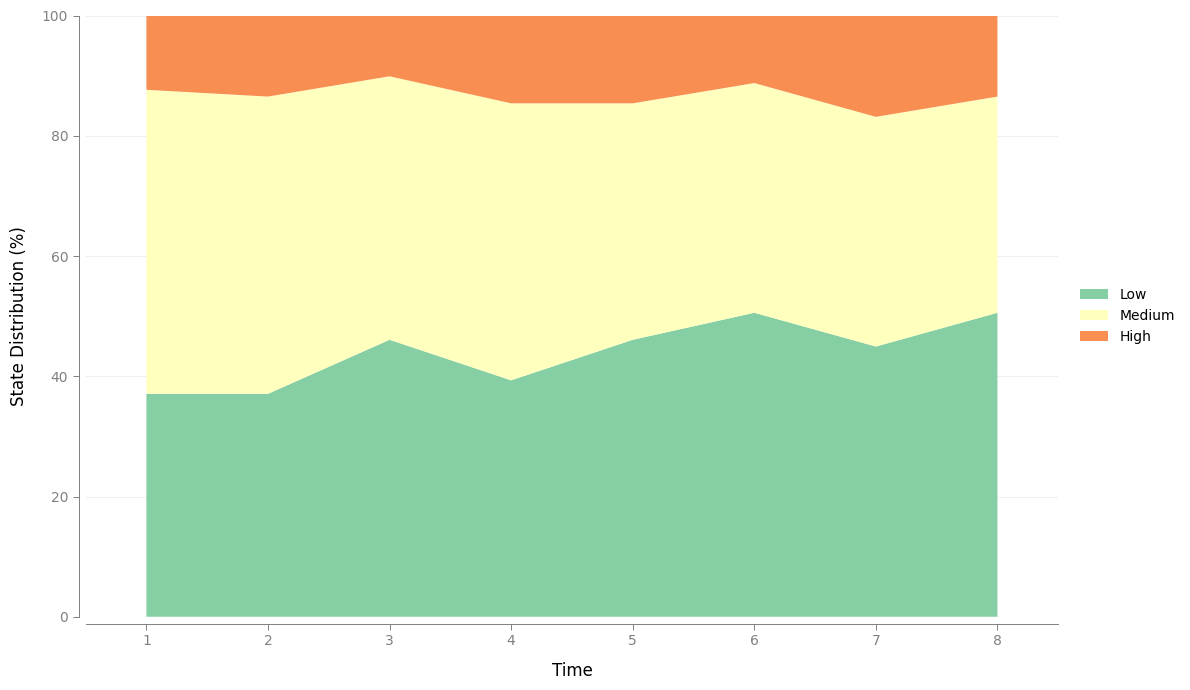

In [10]:
plot_state_distribution(sequence_data)

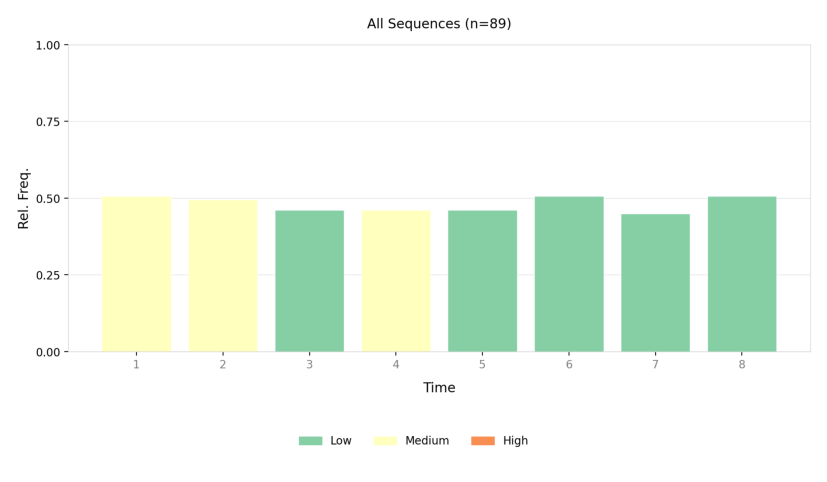

In [11]:
plot_modal_state(sequence_data)

## Dissimilarity Measures

In [12]:
# You can also replace "OMspell" with "OM/DHD/HAM" and "TRATE" with "CONSTANT"
om = get_distance_matrix(seqdata=sequence_data,
                         method="OM",
                         sm="TRATE",
                         indel="auto")
om

[>] Processing 89 sequences with 3 unique states.
[>] Transition-based substitution-cost matrix (TRATE) initiated...
  - Computing transition probabilities for: [L, M, H]
[>] generated an indel of type number

[>] Identified 66 unique sequences.
[>] Starting Optimal Matching(OM)...
[>] Computing all pairwise distances...
[>] Computed Successfully.


,Fall 100,Fall 101,Fall 102,Fall 103,Fall 104,Fall 24,Fall 26,Fall 27,Fall 28,Fall 29,...,Spring 139,Spring 142,Spring 143,Spring 144,Spring 147,Spring 149,Spring 15,Spring 150,Spring 170,Spring 7
Fall 100,0.000000,7.939416,8.020704,5.409274,2.956465,4.982951,10.392225,11.403491,3.890397,8.020704,...,3.464075,4.901664,10.392225,3.464075,6.420540,4.475341,10.977168,6.420540,9.458292,9.458292
Fall 101,7.939416,0.000000,1.945199,6.928150,8.020704,3.037752,6.765575,3.890397,8.020704,1.945199,...,9.113257,6.501827,6.765575,9.113257,3.464075,5.409274,3.464075,6.075505,3.464075,1.518876
Fall 102,8.020704,1.945199,0.000000,8.365738,9.539580,3.037752,6.765575,3.890397,9.965902,0.000000,...,9.113257,7.594381,6.765575,9.113257,4.556629,4.982951,3.464075,6.928150,1.945199,1.518876
Fall 103,5.409274,6.928150,8.365738,0.000000,4.982951,7.780795,7.354472,8.365738,3.464075,8.365738,...,6.501827,3.890397,7.354472,6.501827,5.327986,5.409274,7.939416,3.382787,8.365738,7.939416
Fall 104,2.956465,8.020704,9.539580,4.982951,0.000000,6.501827,12.337423,11.484778,1.518876,9.539580,...,1.518876,3.464075,12.337423,1.518876,6.501827,4.556629,11.058456,4.556629,9.539580,9.539580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Spring 149,4.475341,5.409274,4.982951,5.409274,4.556629,3.890397,7.780795,6.928150,4.982951,4.982951,...,6.075505,3.464075,7.780795,6.075505,1.945199,0.000000,6.501827,3.464075,4.982951,4.982951
Spring 15,10.977168,3.464075,3.464075,7.939416,11.058456,6.501827,6.257964,1.437589,9.539580,3.464075,...,12.577332,8.020704,4.312766,12.577332,4.982951,6.501827,0.000000,6.501827,1.518876,1.945199
Spring 150,6.420540,6.075505,6.928150,3.382787,4.556629,6.928150,7.780795,6.928150,3.037752,6.928150,...,6.075505,1.945199,7.780795,6.075505,3.464075,3.464075,6.501827,0.000000,6.928150,6.501827
Spring 170,9.458292,3.464075,1.945199,8.365738,9.539580,4.982951,6.257964,1.945199,9.965902,1.945199,...,11.058456,8.020704,4.820376,11.058456,4.982951,4.982951,1.518876,6.928150,0.000000,1.945199


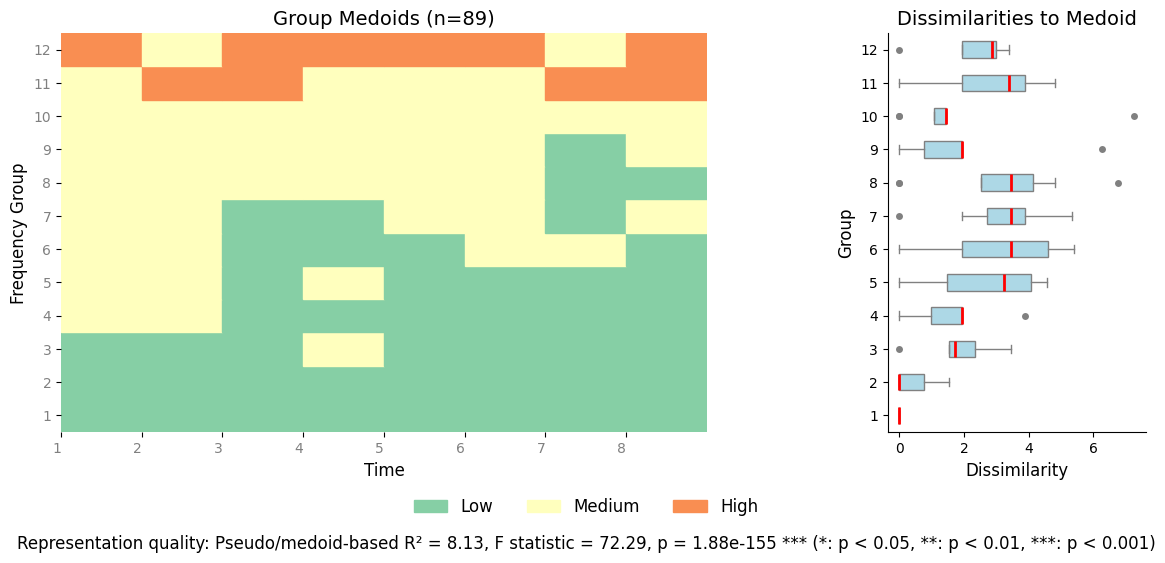

In [13]:
plot_relative_frequency(seqdata=sequence_data, 
                        distance_matrix=om, 
                        num_groups=12, 
                        dpi=200, 
                        # save_as='relative_frequency_plot'
                        )

## Cluster Analysis

[>] Converting DataFrame to NumPy array...


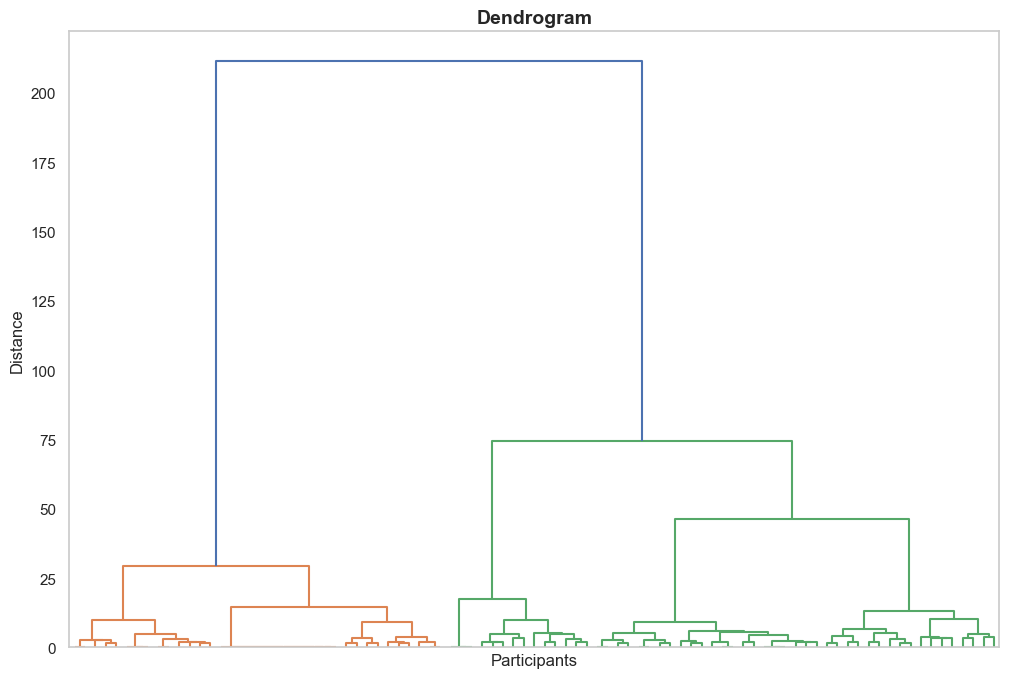

In [14]:
cluster = Cluster(om, sequence_data.ids, clustering_method='ward_d')
cluster.plot_dendrogram(xlabel="Participants", ylabel="Distance")

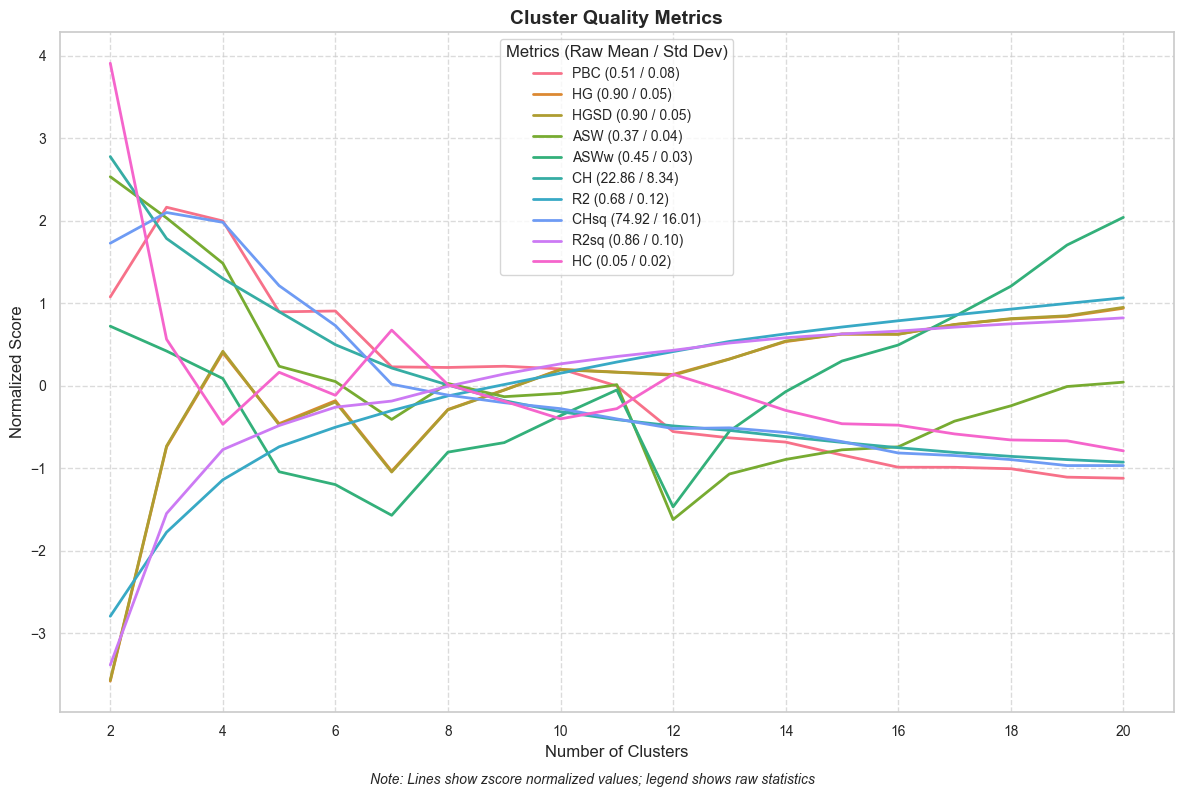

  Metric  Opt. Clusters   Raw Value  Z-Score Norm.
0    PBC              3    0.684171       2.164592
1     HG             20    0.952183       0.939048
2   HGSD             20    0.946349       0.950123
3    ASW              2    0.458768       2.534563
4   ASWw             20    0.512679       2.041628
5     CH              2   46.019930       2.778418
6     R2             20    0.806418       1.065882
7   CHsq              3  108.555704       2.100714
8   R2sq             20    0.942396       0.822823
9     HC              2    0.139196       3.910970


In [15]:
# Create a ClusterQuality object to evaluate clustering quality
cluster_quality = ClusterQuality(cluster)

cluster_quality.compute_cluster_quality_scores()

cluster_quality.plot_cqi_scores(norm='zscore')

summary_table = cluster_quality.get_cqi_table()

print(summary_table)

     Entity ID  Cluster
0     Fall 100        1
1     Fall 101        3
2     Fall 102        3
3     Fall 103        3
4     Fall 104        1
..         ...      ...
84  Spring 149        3
85   Spring 15        3
86  Spring 150        3
87  Spring 170        3
88    Spring 7        3

[89 rows x 2 columns]
   Cluster  Count  Percentage
0        1     36       40.45
1        2     14       15.73
2        3     39       43.82


/Users/lei/Documents/Sequenzo_all_folders/Sequenzo/sequenzo/clustering/hierarchical_clustering.py:1183: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Cluster', y=y_column, data=distribution, palette='pastel')


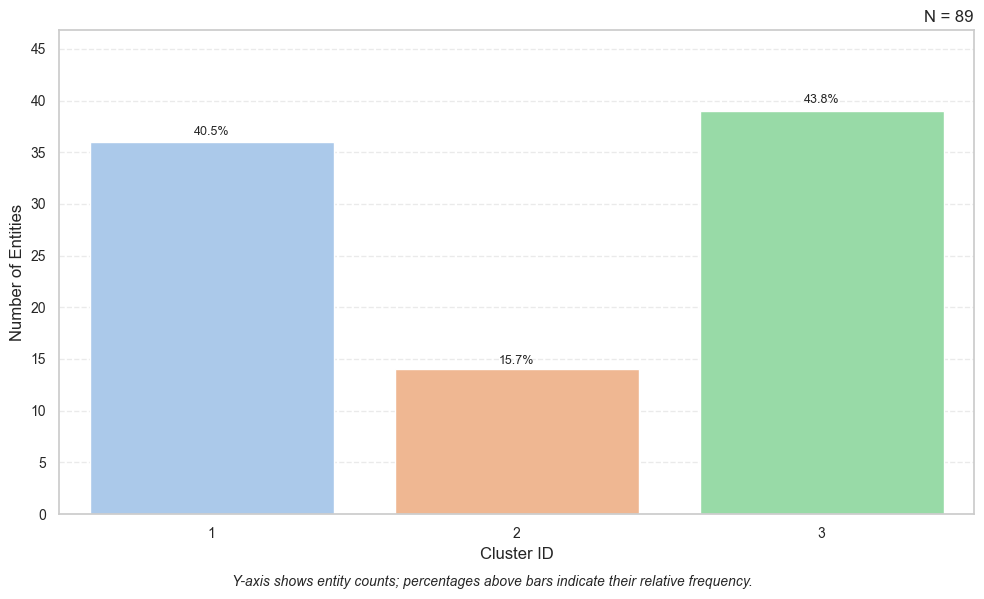

In [16]:
cluster_results = ClusterResults(cluster)

membership_table = cluster_results.get_cluster_memberships(num_clusters=3)

print(membership_table)

distribution = cluster_results.get_cluster_distribution(num_clusters=3)

print(distribution)

cluster_results.plot_cluster_distribution(num_clusters=3, title=None)


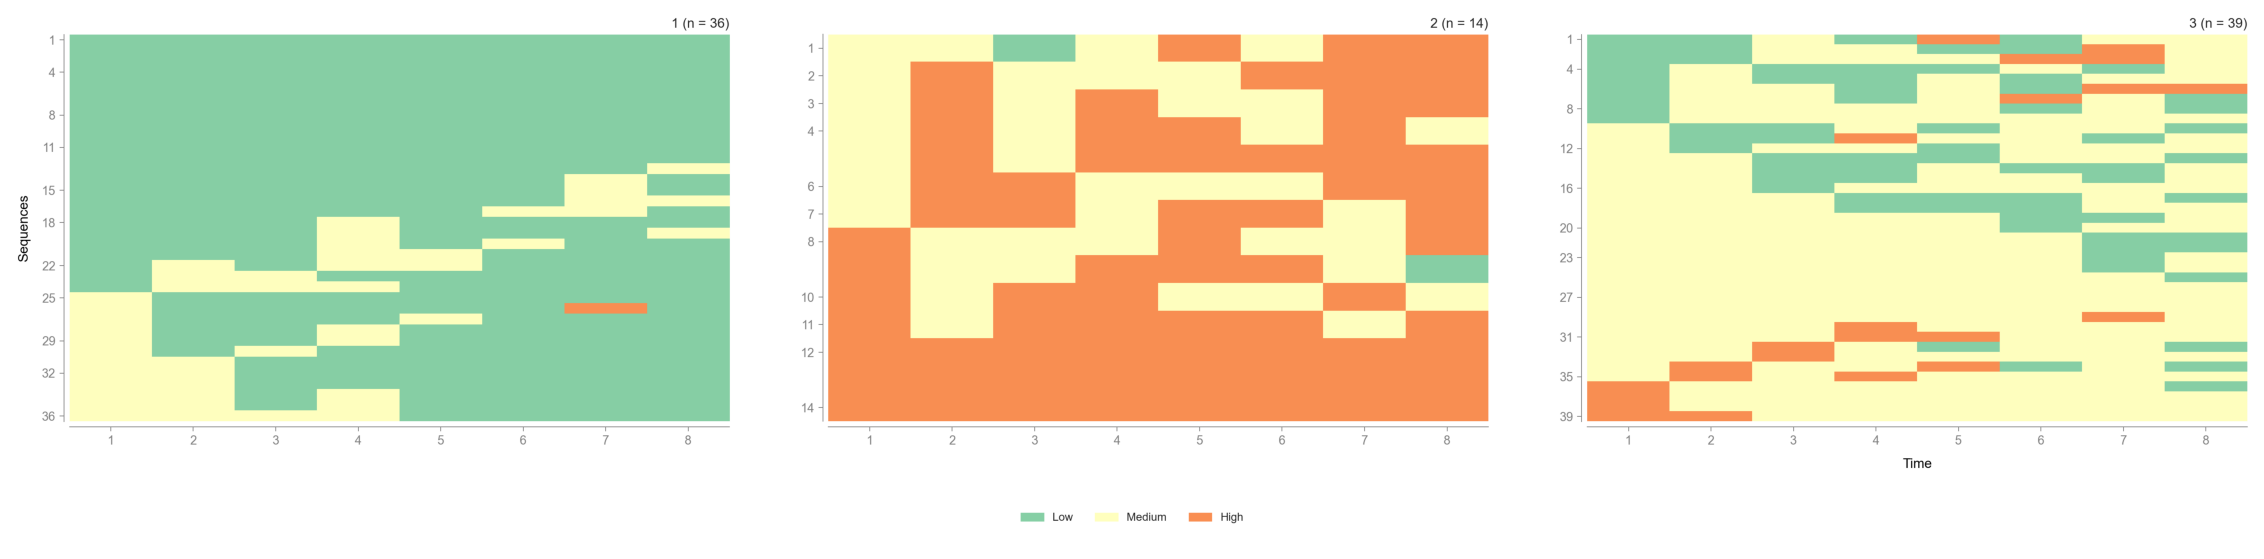

In [17]:
plot_sequence_index(seqdata=sequence_data,
                    group_dataframe=membership_table,
                    group_column_name="Cluster",
                    )

We summarize the **three clusters** of stress trajectories as follows:

**Cluster 1 (Stable Low)** – Most sequences in this cluster stay in the **Low** (green) stress state across the 8 weeks. Some participants have short spells of **Medium** (yellow), and only rarely **High** (orange). This group represents students who maintained low perceived stress for most of the period.

**Cluster 2 (Sustained High)** – This cluster is dominated by **High** (orange) stress, especially from around week 3 onward. In the first weeks there is often a mix of **Medium** (yellow) and **High**; many students then shift to and stay in **High**. **Low** (green) appears only as brief dips. These are students who reported elevated stress for much of the 8 weeks.

**Cluster 3 (Mixed and Fluctuating)** – Here we see a mix of all three states and more change over time. **Medium** (yellow) is often a baseline, with frequent transitions to **Low** (green) or **High** (orange). There is no single long-term stable pattern; trajectories vary a lot within the cluster. This group captures students with more variable stress over the 8 weeks.

In [18]:
cluster_labels = {
    1: 'Stable Low',
    2: 'Sustained High',
    3: 'Mixed and Fluctuating',
}

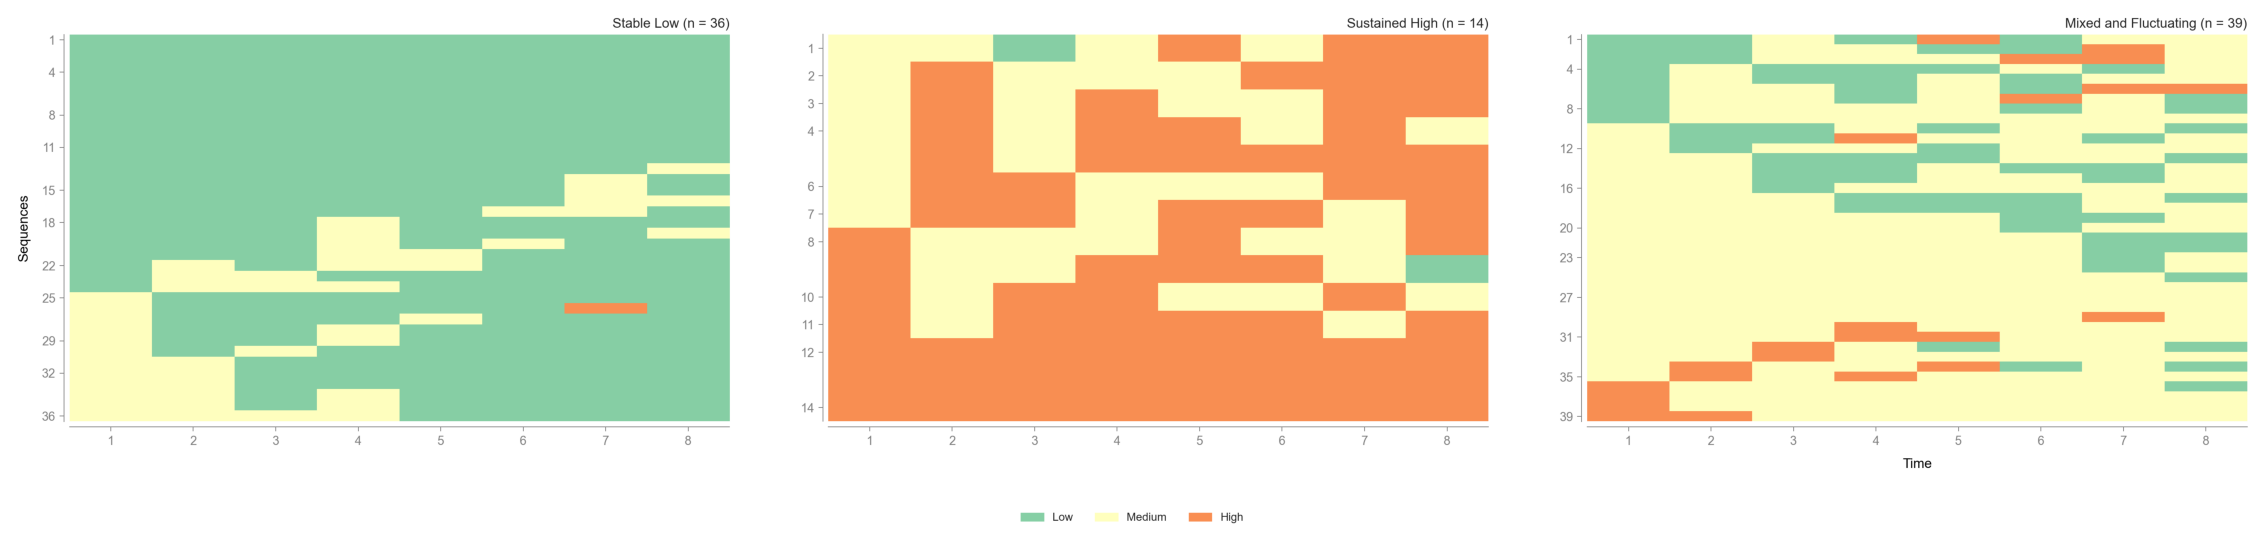

In [19]:
plot_sequence_index(seqdata=sequence_data,
                    group_dataframe=membership_table,
                    group_column_name="Cluster",
                    group_labels=cluster_labels,
                    )

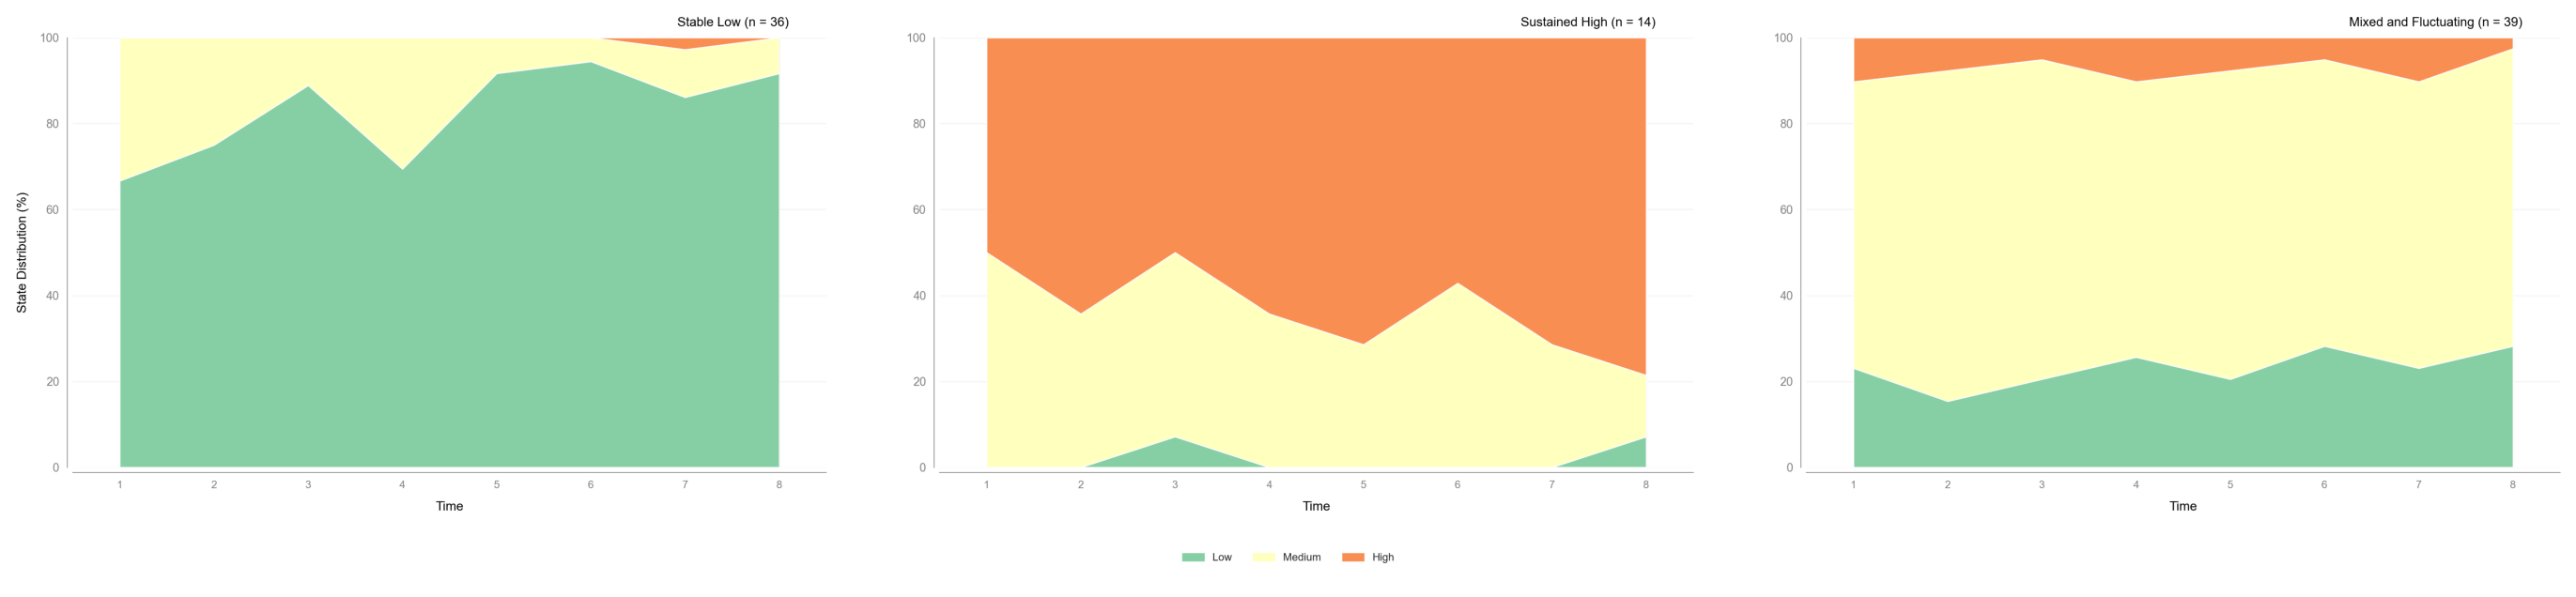

In [20]:
plot_state_distribution(seqdata=sequence_data,
                        group_dataframe=membership_table,
                        group_column_name="Cluster",
                        group_labels=cluster_labels,
                        # save_as='cluster_state_distribution_plot'
                        )

In [21]:
# Prepare the dataframe for regression analysis

membership_table.rename(columns={'Entity ID': 'participant_id'}, inplace=True)

df_with_membership = pd.merge(df, membership_table, on='participant_id', how='left')

# Add an additional column to the dataframe, i.e., the values of Cluster to the labels
df_with_membership['Cluster_labels'] = df_with_membership['Cluster'].map(cluster_labels)

df_with_membership

,participant_id,cohort,1,2,3,4,5,6,7,8,Cluster,Cluster_labels
0,Fall 100,Fall,M,L,L,L,L,L,H,L,1,Stable Low
1,Fall 101,Fall,M,M,M,M,M,L,L,M,3,Mixed and Fluctuating
2,Fall 102,Fall,M,M,M,M,M,M,L,L,3,Mixed and Fluctuating
3,Fall 103,Fall,L,L,M,L,H,L,M,M,3,Mixed and Fluctuating
4,Fall 104,Fall,L,L,L,L,L,L,M,L,1,Stable Low
...,...,...,...,...,...,...,...,...,...,...,...,...
84,Spring 149,Spring,M,M,L,L,L,M,M,L,3,Mixed and Fluctuating
85,Spring 15,Spring,H,M,M,M,M,M,M,M,3,Mixed and Fluctuating
86,Spring 150,Spring,L,M,L,L,M,L,M,M,3,Mixed and Fluctuating
87,Spring 170,Spring,H,M,M,M,M,M,M,L,3,Mixed and Fluctuating


## Regression

## Conclusions